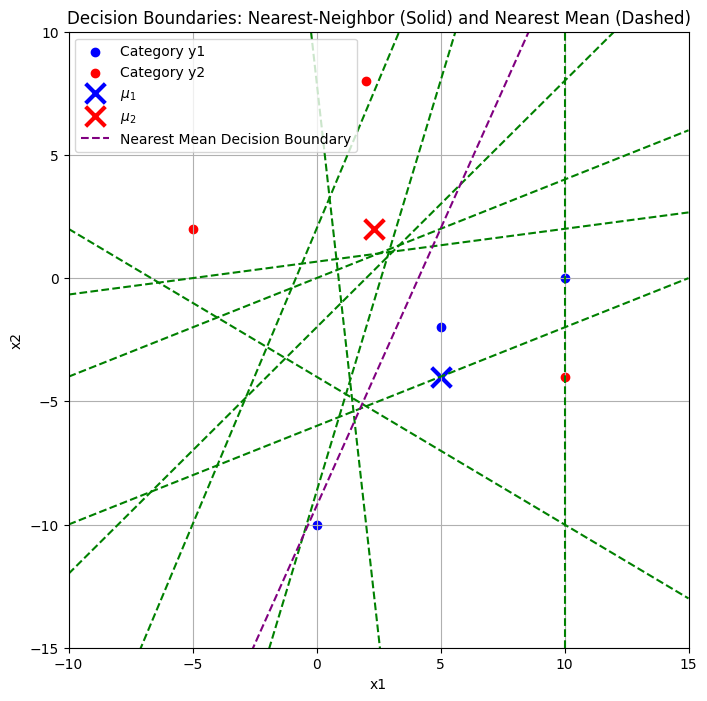

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data points from the problem
y1_points = np.array([[10, 0], [0, -10], [5, -2]])  # category y1
y2_points = np.array([[2, 8], [-5, 2], [10, -4]])   # category y2

# (i) Plot the decision boundary for nearest-neighbor classification

# Function to calculate the midpoint and perpendicular bisector slope
def midpoint(p1, p2):
    return (p1 + p2) / 2

def perpendicular_slope(p1, p2):
    if (p1[0] - p2[0]) != 0:
        return -(p1[1] - p2[1]) / (p1[0] - p2[0])
    else:
        return float('inf')  # Vertical line

# Plot setup
plt.figure(figsize=(8, 8))

# Scatter plot for y1 and y2 points
plt.scatter(y1_points[:, 0], y1_points[:, 1], color='blue', label='Category y1')
plt.scatter(y2_points[:, 0], y2_points[:, 1], color='red', label='Category y2')

# For each pair of y1 and y2 points, draw the perpendicular bisectors
for i in range(len(y1_points)):
    for j in range(len(y2_points)):
        p1, p2 = y1_points[i], y2_points[j]
        mid = midpoint(p1, p2)
        slope = perpendicular_slope(p1, p2)
        
        if slope == float('inf'):
            # Vertical line (infinite slope)
            plt.axvline(mid[0], color='green', linestyle='--')
        else:
            # Regular line with slope
            x_vals = np.linspace(-10, 15, 200)
            y_vals = slope * (x_vals - mid[0]) + mid[1]
            plt.plot(x_vals, y_vals, 'g--')

# (ii) Calculate the means of both categories and plot the decision boundary using nearest mean rule

# Mean for category y1
mu1 = np.mean(y1_points, axis=0)
# Mean for category y2
mu2 = np.mean(y2_points, axis=0)

# Plot the means
plt.scatter(mu1[0], mu1[1], color='blue', marker='x', s=200, label=r'$\mu_1$', linewidths=3)
plt.scatter(mu2[0], mu2[1], color='red', marker='x', s=200, label=r'$\mu_2$', linewidths=3)

# Plot the decision boundary (perpendicular bisector) between the means
mid_mean = midpoint(mu1, mu2)
slope_mean = perpendicular_slope(mu1, mu2)

# Plot decision boundary for nearest mean
if slope_mean == float('inf'):
    plt.axvline(mid_mean[0], color='purple', linestyle='--', label='Nearest Mean Decision Boundary')
else:
    y_vals_mean = slope_mean * (x_vals - mid_mean[0]) + mid_mean[1]
    plt.plot(x_vals, y_vals_mean, 'purple', linestyle='--', label='Nearest Mean Decision Boundary')

# Add labels, legend, and title
plt.xlim([-10, 15])
plt.ylim([-15, 10])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision Boundaries: Nearest-Neighbor (Solid) and Nearest Mean (Dashed)')
plt.legend()

# Display the plot
plt.grid(True)
plt.show()
